# BPIC17 Dataset Overview

In [1]:
import sys
from pathlib import Path
from collections import Counter

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

# Get activity mapping
cat_features = model.data_set_categories[0]
activity_idx = next(i for i, (n, _, _) in enumerate(cat_features) if n == CONFIG.concept_name)
activity_map = {v: k for k, v in cat_features[activity_idx][2].items()}

print(f"Test samples: {len(test_dataset)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [2]:
# Extract sequences per case with ALL features

# Build feature mappings for all categorical features
feature_maps = {}
feature_indices = {}
for i, (name, n_vals, mapping) in enumerate(cat_features):
    feature_maps[name] = {v: k for k, v in mapping.items()}
    feature_indices[name] = ('cat', i)

# For numerical features
num_features = model.data_set_categories[1]
for i, (name, _, _) in enumerate(num_features):
    feature_indices[name] = ('num', i)

all_feature_names = [n for n, _, _ in cat_features] + [n for n, _, _ in num_features]

# Extract full event data per case
cases = {}  # case_name -> list of event dicts
for cat_tensors, num_tensors, case_name in test_dataset:
    events = []
    seq_len = cat_tensors[0].shape[0]
    
    for pos in range(seq_len):
        # Skip padding
        act_val = cat_tensors[feature_indices['concept:name'][1]][pos].item()
        if act_val == 0:
            continue
        act_name = feature_maps['concept:name'].get(act_val, '?')
        if act_name in ['EOS', 'PAD']:
            continue
        
        event = {}
        for feat, (feat_type, idx) in feature_indices.items():
            if feat_type == 'num':
                event[feat] = num_tensors[idx][pos].item()
            else:
                val = cat_tensors[idx][pos].item()
                event[feat] = feature_maps[feat].get(val, '?')
        events.append(event)
    
    # Keep longest per case
    if case_name not in cases or len(events) > len(cases[case_name]):
        cases[case_name] = events

# For sequence counting, use activity tuple
activity_seqs = {k: tuple(e['concept:name'] for e in v) for k, v in cases.items()}
lengths = [len(seq) for seq in cases.values()]

print(f"Cases: {len(cases)}")
print(f"Avg length: {np.mean(lengths):.1f}, Min/Max: {min(lengths)}/{max(lengths)}, Median: {np.median(lengths):.0f}")
print(f"Features per event: {len(all_feature_names)}")

Cases: 6301
Avg length: 38.0, Min/Max: 10/96, Median: 34
Features per event: 18


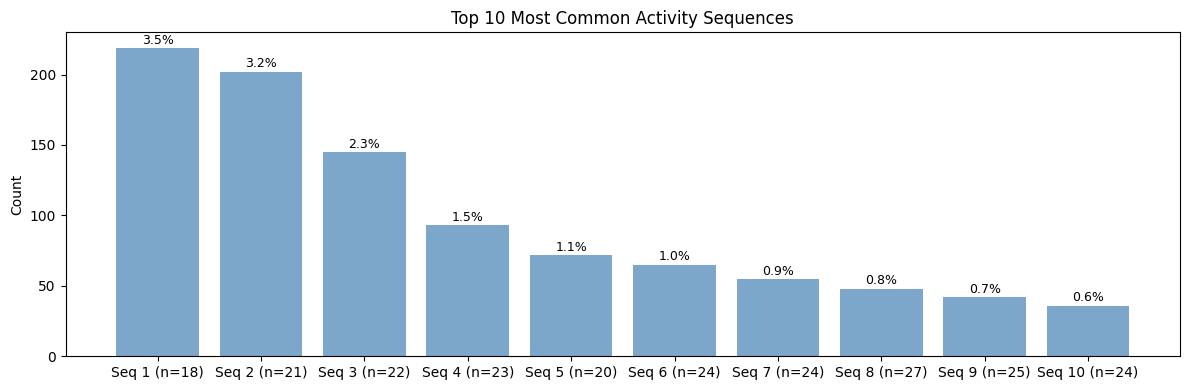


TOP SEQUENCES: Activity Pattern + Feature Variability

[Sequence 1] Count: 219 cases (3.5%), Length: 18
----------------------------------------------------------------------------------------------------
Example cases: Application_1031358870, Application_104317572, Application_1068537601, Application_1068716105, Application_1072056987

Activity pattern:
  E1: A_Create Application
  E2: W_Complete application
  E3: W_Complete application
  E4: A_Concept
  E5: A_Accepted
  E6: O_Create Offer
  E7: O_Created
  E8: O_Sent (mail and online)
  E9: W_Complete application
  E10: W_Call after offers
  E11: W_Call after offers
  E12: A_Complete
  E13: W_Call after offers
  E14: W_Call after offers
  E15: W_Call after offers
  E16: A_Cancelled
  E17: O_Cancelled
  E18: W_Call after offers

Feature variability across 219 cases:
  Action: varies (avg 1.2, max 3 unique values per position)
  org:resource: varies (avg 54.1, max 64 unique values per position)
  EventOrigin: CONSTANT across all cases

In [3]:
# Top 10 most common sequences - show activity pattern + feature variability
import matplotlib.pyplot as plt
import pandas as pd

seq_counts = Counter(activity_seqs.values())
top_10 = seq_counts.most_common(10)

# Group cases by activity sequence
seq_to_cases = {}
for case_name, seq in activity_seqs.items():
    if seq not in seq_to_cases:
        seq_to_cases[seq] = []
    seq_to_cases[seq].append(case_name)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 4))
labels = [f"Seq {i+1} (n={len(seq)})" for i, (seq, _) in enumerate(top_10)]
counts = [c for _, c in top_10]
bars = ax.bar(labels, counts, color='steelblue', alpha=0.7)
ax.set_ylabel('Count')
ax.set_title('Top 10 Most Common Activity Sequences')
for bar, (_, cnt) in zip(bars, top_10):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            f'{100*cnt/len(activity_seqs):.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# For each top sequence, show the activity pattern and feature variability
print(f"\n{'='*100}")
print("TOP SEQUENCES: Activity Pattern + Feature Variability")
print(f"{'='*100}")

for rank, (seq, count) in enumerate(top_10[:5], 1):
    case_names_for_seq = seq_to_cases[seq]
    
    print(f"\n[Sequence {rank}] Count: {count} cases ({100*count/len(activity_seqs):.1f}%), Length: {len(seq)}")
    print("-" * 100)
    
    # Show example case IDs
    example_cases = case_names_for_seq[:5]
    print(f"Example cases: {', '.join(example_cases)}")
    
    # Show activity sequence
    print("\nActivity pattern:")
    for i, act in enumerate(seq):
        print(f"  E{i+1}: {act}")
    
    # Analyze feature variability across all cases with this pattern
    print(f"\nFeature variability across {count} cases:")
    
    # Collect feature values at each position
    cat_features_to_check = ['Action', 'org:resource', 'EventOrigin', 'lifecycle:transition']
    
    for feat in cat_features_to_check:
        # Count unique values per position
        position_values = {}
        for case_name in case_names_for_seq:
            events = cases[case_name]
            for pos, event in enumerate(events):
                if pos not in position_values:
                    position_values[pos] = []
                position_values[pos].append(event.get(feat, '?'))
        
        # Summarize: how many unique values across positions?
        unique_counts = [len(set(position_values[p])) for p in sorted(position_values.keys())]
        avg_unique = sum(unique_counts) / len(unique_counts) if unique_counts else 0
        max_unique = max(unique_counts) if unique_counts else 0
        
        if max_unique == 1:
            print(f"  {feat}: CONSTANT across all cases")
        else:
            print(f"  {feat}: varies (avg {avg_unique:.1f}, max {max_unique} unique values per position)")
    
    print()

In [4]:
# Activity frequency
all_acts = [e['concept:name'] for events in cases.values() for e in events]
act_counts = Counter(all_acts)
print(f"Unique activities: {len(act_counts)}")
print("\nTop 10 activities:")
for act, count in act_counts.most_common(10):
    print(f"  {act}: {count} ({100*count/len(all_acts):.1f}%)")

Unique activities: 25

Top 10 activities:
  W_Validate application: 41547 (17.3%)
  W_Call after offers: 38372 (16.0%)
  W_Call incomplete files: 33340 (13.9%)
  W_Complete application: 29888 (12.5%)
  W_Handle leads: 9382 (3.9%)
  O_Create Offer: 8650 (3.6%)
  O_Created: 8649 (3.6%)
  O_Sent (mail and online): 7980 (3.3%)
  A_Validating: 7656 (3.2%)
  A_Create Application: 6301 (2.6%)


In [5]:
# Features summary
print("Categorical features:")
for name, n_vals, _ in cat_features:
    print(f"  {name}: {n_vals} values")
print(f"\nNumerical features: {[n for n, _, _ in model.data_set_categories[1]]}")

Categorical features:
  concept:name: 28 values
  Action: 7 values
  org:resource: 151 values
  EventOrigin: 5 values
  lifecycle:transition: 9 values
  case:LoanGoal: 16 values
  case:ApplicationType: 4 values
  Accepted: 5 values
  Selected: 5 values

Numerical features: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'MonthlyCost', 'CreditScore']
